In [2]:
import numpy as np
import matplotlib.pyplot as plt
from hiopbbpy.problems import Problem
from hiopbbpy.surrogate_modeling import smtKRG 
from hiopbbpy.opt import BnBAlgorithmBase, LCBacquisition

#### Example 

In [3]:
### parameters
n_samples = 10  # number of the initial samples to train GP
theta = 1.e-2  # hyperparameter for GP kernel
nx = 1         # dimension of the problem
c2D=np.array([1.25, 2.5])
c1D=np.array([1.25])
if nx == 1:
    delta = 10.0
    xlimits = np.array([[0.75 - delta/2.,0.75 + delta/2.]])
    c1D = np.array([0.75])
    c = c1D
elif nx == 2:
    c = c2D

class QuadraticShift(Problem):
    """
    f(x) = ||x - c||^2
    - Global minimizer: x* = c
    - Global minimum:   f* = 0
    """
    def __init__(self, ndim=2, xlimits=None, c=None, constraints=[]):
        if xlimits is None:
            xlimits = np.array([[-5.0, 5.0]] * ndim, dtype=float)
        name = "QuadraticShift"
        super().__init__(ndim, xlimits, name=name, constraints=constraints)

        # choose center if not provided
        if c is None:
            c = self.xlimits.mean(axis=1)
        self.c = np.asarray(c, dtype=float)
        assert self.c.shape == (ndim,), "c must be a {0:d}D point".format(ndim)

        # expose known solution for checking later
        # below is true when c is in xlimits
        self.x_star = self.c.copy()
        self.f_star = 0.0 

    def _evaluate(self, x: np.ndarray) -> np.ndarray:
        ne, nx = x.shape
        assert nx == self.ndim
        diff = x - self.c[None, :]
        y = np.sum(diff * diff, axis=1, dtype=float).reshape(ne, 1)
        return y

if nx == 1:
    problem = QuadraticShift(ndim=nx, xlimits=xlimits, c=c)
else:
    problem = QuadraticShift(ndim=nx, c=c)
problem.set_constraints([])  
    
x_train = problem.sample(n_samples)
y_train = problem.evaluate(x_train)

gp_model = smtKRG(theta, problem.xlimits, nx)
gp_model.train(x_train, y_train)

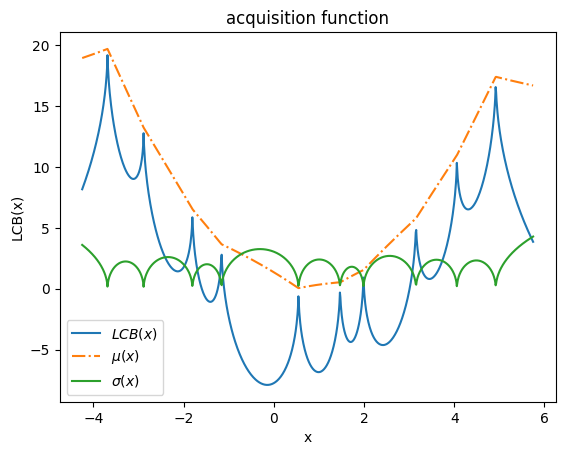

In [4]:
l = problem.xlimits[:, 0].astype(float)
u = problem.xlimits[:, 1].astype(float)
n_plot_pts = 1000
X = np.atleast_2d(np.linspace(l[0], u[0], n_plot_pts)).transpose()

muX = gp_model.mean(X)
sigmaX = np.sqrt(gp_model.variance(X))
beta = 3.0

acqf = LCBacquisition(gp_model, beta=beta)
Y_acqf = acqf.evaluate(X)

plt.plot(X, Y_acqf, label=r'$LCB(x)$')
plt.plot(X, muX, "-.", label=r'$\mu(x)$')
plt.plot(X, sigmaX, label=r'$\sigma(x)$')
plt.xlabel("x")
plt.ylabel("LCB(x)")
plt.legend()
plt.title("acquisition function")
plt.show()

In [5]:
# ---- Use only BnBAlgorithmBase methods + SMT predict_* for reference ----

sm = gp_model.surrogatesmt

# Build a base "probe" and populate it from the trained SMT model
base = BnBAlgorithmBase(x=x_train, y=y_train)
base.gpsurrogate = gp_model
base.sync_from_smt()              # fills kernel_spec/p, theta, Xc, offsets, beta0/gamma, C, sigma2

# (Optional) ensure we try to compute a nontrivial lower bound for variance
base.BnB_LBmethod = "IPOPT"          # if "IPOPT", sigma2_L will be 0 in your current code
base.beta = beta
# Pick a box to test (use full domain here; swap l/u to any node box you want)
l = problem.xlimits[:, 0].astype(float)
u = problem.xlimits[:, 1].astype(float)

nboxes = 75
box_sizes = (u - l) / float(nboxes)
midpoints = np.zeros((nboxes,))
kLs = np.zeros((nboxes, n_samples))
kUs = np.zeros((nboxes, n_samples))
muLs = np.zeros((nboxes,))
muUs = np.zeros((nboxes,))
s2Ls = np.zeros((nboxes,))
s2Us = np.zeros((nboxes,))
LCB_Ls = np.zeros((nboxes,) * nx)
LCB_Us = np.zeros((nboxes,) * nx)

for i in range(nboxes):
    for j in range(nboxes):
        if nx == 2:
            li = l + np.array([i * box_sizes[0], j * box_sizes[1]])
            ui = l + np.array([(i + 1) * box_sizes[0], (j +1) * box_sizes[1]])
        else:
            if j > 0:
                continue
            li = l + i * box_sizes[0]
            ui = l + (i + 1) * box_sizes[0]
        midpoints[i] = (li[0] + ui[0]) / 2.

        # 1) Bounds from your base class 
        kL, kU         = base.ker_bounds(li, ui)     # per-point kernel bounds vs each trainingsample
        mu_L, mu_U     = base.mu_bounds(kL, kU)      # scalar μ bounds on the box
        s2_L, s2_U     = base.sigma2_bounds(kL, kU)  # scalar σ² bounds on the box
        
        # 2) (Optional) Node LCB/EI bounds using ONLY base.rs_* with your bounds
        LCB_L = base.rs_lcb(mu_L, np.sqrt(max(s2_U, 0.0)))     # lower bound on LCB over the box
        LCB_U = base.rs_lcb(mu_U, np.sqrt(max(s2_L, 0.0)))     # upper bound on LCB over the box
        #print(f"LCB node bounds:  L={LCB_L:.9f}   U={LCB_U:.9f}")
        if nx == 1:
            LCB_Ls[i] = LCB_L
            LCB_Us[i] = LCB_U
            midpoints[i] = (li[0] + ui[0]) / 2.
        elif nx == 2:
            LCB_Ls[i][j] = LCB_L
            LCB_Us[i][j] = LCB_U
        
        

        muLs[i] = mu_L
        muUs[i] = mu_U
        s2Ls[i] = s2_L
        s2Us[i] = s2_U
        kLs[i,:] = kL[:]
        kUs[i,:] = kU[:]       
mu = gp_model.mean(midpoints)
s2 = gp_model.variance(midpoints)

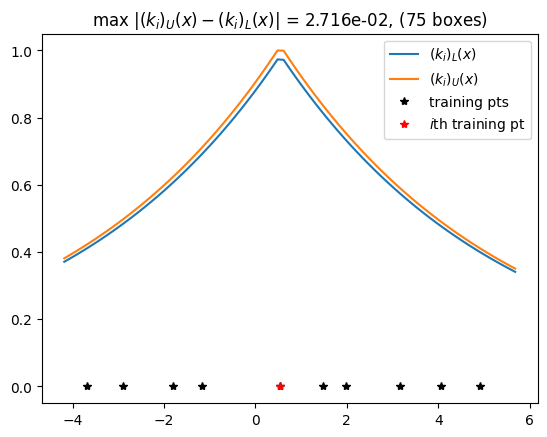

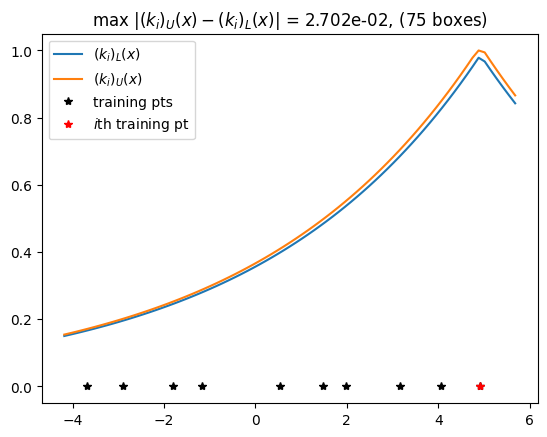

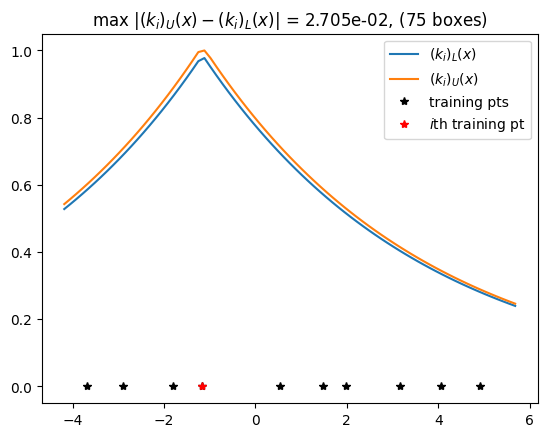

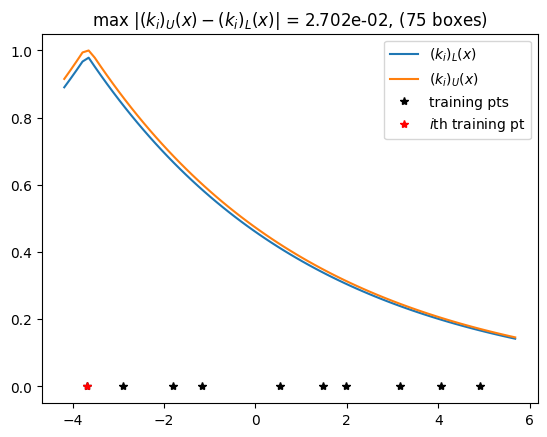

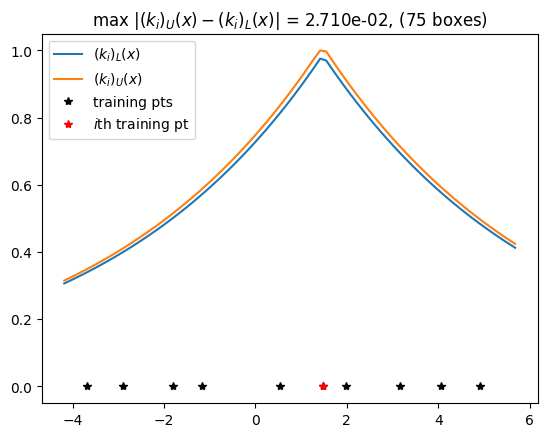

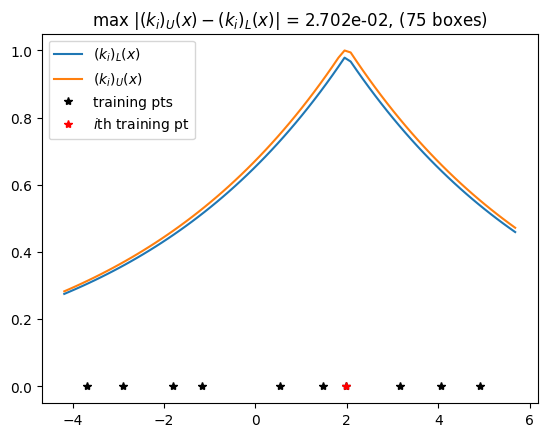

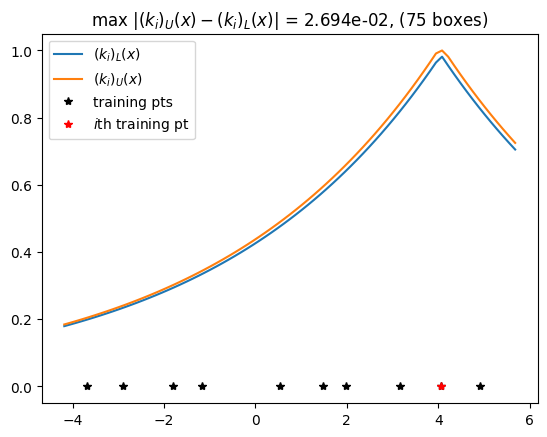

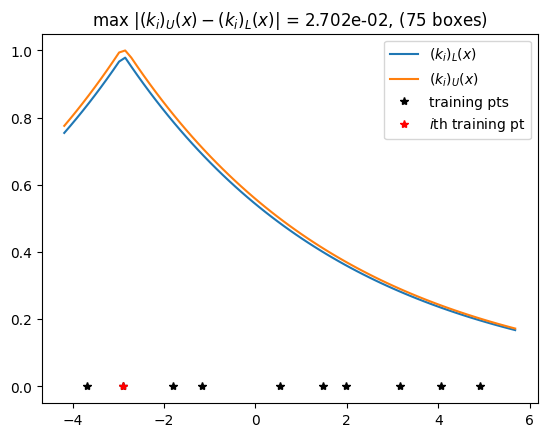

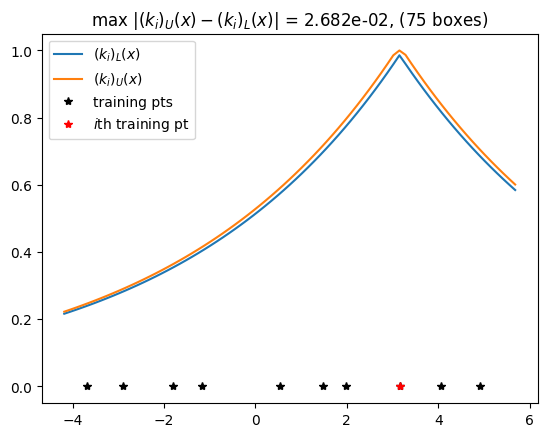

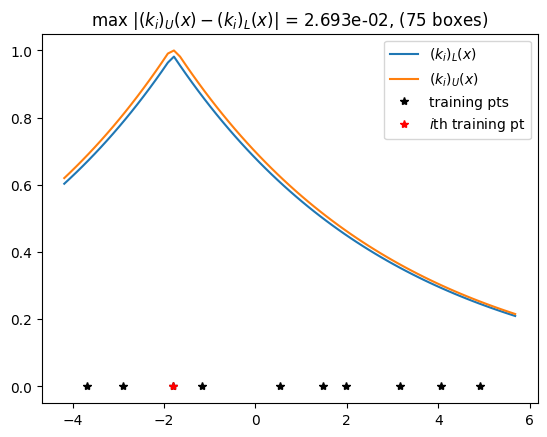

In [6]:
K_bandgaps = [np.linalg.norm(kUs[:,i] - kLs[:,i], np.inf) for i in range(n_samples)]

for i in range(n_samples):
    plt.plot(midpoints, kLs[:,i], label=r'$(k_i)_L(x)$')
    plt.plot(midpoints, kUs[:,i], label=r'$(k_i)_U(x)$')
    plt.plot(x_train[:,0], np.zeros(n_samples), "k*", label=r'training pts')
    plt.plot(x_train[i,0], np.zeros(1), "r*", label=r'$i$th training pt')
    plt.legend()
    plt.title(r"max $|(k_i)_U(x) - (k_i)_L(x)|$ = {0:1.3e}, ({1:d} boxes)".format(K_bandgaps[i], nboxes))
    plt.show()

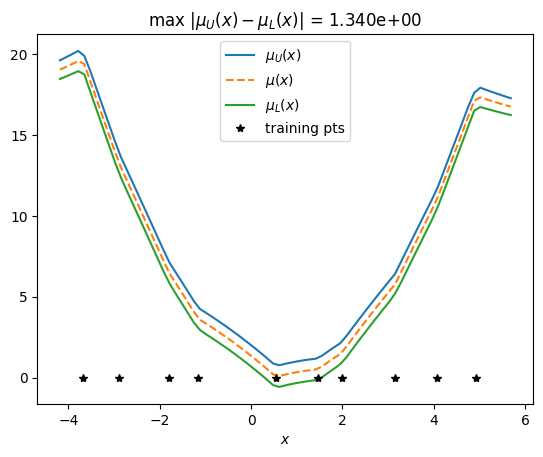

In [7]:
mu_bandgap = np.linalg.norm(muUs - muLs, np.inf)

plt.plot(midpoints, muUs, label=r'$\mu_U(x)$')
plt.plot(midpoints, mu, "--", label=r'$\mu(x)$')
plt.plot(midpoints, muLs, label=r'$\mu_L(x)$')
plt.plot(x_train[:,0], np.zeros(n_samples), "k*", label=r'training pts')
plt.xlabel(r"$x$")
plt.legend()
plt.title(r"max $|\mu_U(x) - \mu_L(x)|$ = {0:1.3e}".format(mu_bandgap))
plt.show()

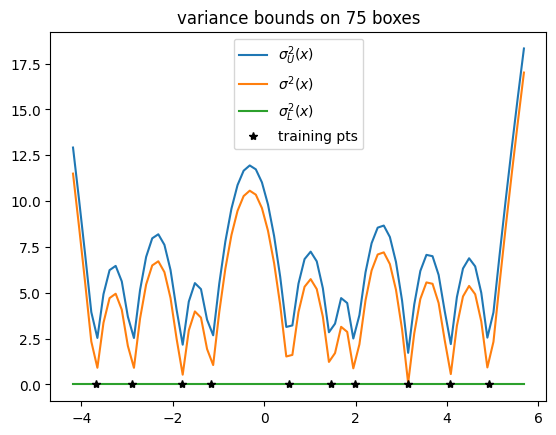

In [8]:
plt.plot(midpoints, s2Us, label=r"$\sigma^{2}_{U}(x)$")
plt.plot(midpoints, s2, label=r"$\sigma^{2}(x)$")
plt.plot(midpoints, s2Ls, label=r"$\sigma^{2}_{L}(x)$")
plt.plot(x_train[:,0], np.zeros(n_samples), "k*", label=r'training pts')
plt.title('variance bounds on {0:d} boxes'.format(nboxes))
plt.legend()
plt.show()

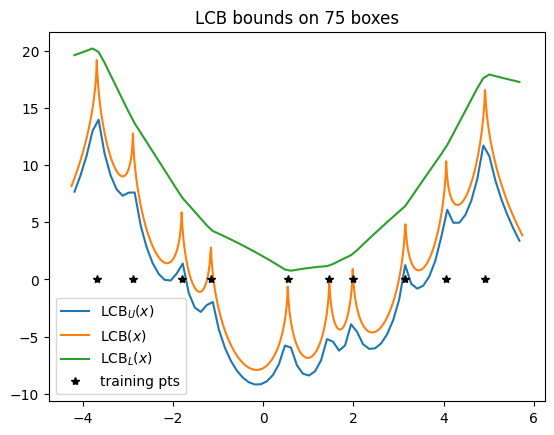

In [9]:
plt.plot(midpoints, LCB_Ls, label=r"LCB$_{U}(x)$")
plt.plot(X, Y_acqf, label=r'LCB$(x)$')
plt.plot(midpoints, LCB_Us, label=r"LCB$_{L}(x)$")
plt.plot(x_train[:,0], np.zeros(n_samples), "k*", label=r'training pts')
plt.title('LCB bounds on {0:d} boxes'.format(nboxes))
plt.legend()
plt.show()

In [10]:
from hiopbbpy.opt import minimizer_wrapper

In [11]:
acqf_callback = {'obj': acqf.scalar_evaluate}
acqf_callback['grad'] = acqf.scalar_eval_g
opt_solver = "SLSQP"
acqf_minimizer=minimizer_wrapper(acqf_callback, opt_solver, problem.xlimits, [], {})

In [12]:
from hiopbbpy.opt import BnBAlgorithm
bnb = BnBAlgorithm(x_train, y_train, gpsurrogate=gp_model, 
                   acqf_minimizer_callback=acqf_minimizer.minimizer_callback,
                   acquisition_type="LCB")
bnb.epsilon_diam = 1.e-4
bnb.epsilon_gap = 1.e-4

In [13]:
bnb.optimize(problem.xlimits[:,0], problem.xlimits[:,1])

=== Starting Branch & Bound Optimization (Minimization) ===
Initial bounds: l = [-4.25], u = [5.75]
Number of points: 10, Dim = 1

Initial acquisition lower bound: -48.91945794325531
Initial acquisition upper bound: 8.165071689581389

--- Iteration 1 ---
Node bounds: l=[-4.25], u=[5.75]
Node acquisition bounds: L=-48.91945794325531, U=8.165071689581389
Current best feasible value (GUB): 8.165071689581389
  Branching to child: l=[-4.25], u=[0.75]
  Child acquisition bounds: L=-32.316325124991664, U=-7.909361476060862
  Branching to child: l=[0.75], u=[5.75]
  Child acquisition bounds: L=-32.08576524476935, U=-6.859391782035961
Queue size: 2 | GLB=-32.316325124991664 | GUB=-7.909361476060862 | Gap=24.4069636489308

--- Iteration 2 ---
Node bounds: l=[-4.25], u=[0.75]
Node acquisition bounds: L=-32.316325124991664, U=-7.909361476060862
Current best feasible value (GUB): -7.909361476060862
  Branching to child: l=[-4.25], u=[-1.75]
  Child acquisition bounds: L=-12.540563267627103, U=-6.85

  Child acquisition bounds: L=-8.908311767601488, U=-7.9093615039079355
  Branching to child: l=[-0.34375], u=[-0.1875]
  Child acquisition bounds: L=-9.304267158734422, U=-7.909361107232032
Queue size: 13 | GLB=-10.262338317178104 | GUB=-7.909361503909079 | Gap=2.3529768132690245

--- Iteration 20 ---
Node bounds: l=[0.75], u=[1.0625]
Node acquisition bounds: L=-10.262338317178104, U=-6.859391781638293
Current best feasible value (GUB): -7.909361503909079
  Branching to child: l=[0.75], u=[0.90625]
  Child acquisition bounds: L=-8.28732174446263, U=-6.859391782001111
  Branching to child: l=[0.90625], u=[1.0625]
  Child acquisition bounds: L=-8.665161499871532, U=-6.8593917770629975
Queue size: 14 | GLB=-9.900226226783419 | GUB=-7.909361503909079 | Gap=1.9908647228743392

--- Iteration 21 ---
Node bounds: l=[0.125], u=[0.4375]
Node acquisition bounds: L=-9.900226226783419, U=-7.909361486281745
Current best feasible value (GUB): -7.909361503909079
  Branching to child: l=[0.125], u=[0.

  Child acquisition bounds: L=-7.594309122278694, U=-7.909361503914904
  Child pruned: L ≥ GUB - eps.
  Branching to child: l=[1.140625], u=[1.21875]
  Child acquisition bounds: L=-7.22538047320925, U=-6.8593917821396575
  Child pruned: L ≥ GUB - eps.
Queue size: 20 | GLB=-8.331284523824984 | GUB=-7.90936150391945 | Gap=0.4219230199055337

--- Iteration 37 ---
Node bounds: l=[0.046875], u=[0.125]
Node acquisition bounds: L=-8.331284523824984, U=-7.909361503874411
Current best feasible value (GUB): -7.90936150391945
  Branching to child: l=[0.046875], u=[0.0859375]
  Child acquisition bounds: L=-7.989756908700736, U=-7.909361503431923
  Branching to child: l=[0.0859375], u=[0.125]
  Child acquisition bounds: L=-7.856941817099512, U=-7.909361503877741
  Child pruned: L ≥ GUB - eps.
Queue size: 20 | GLB=-8.295447907305185 | GUB=-7.90936150391945 | Gap=0.3860864033857352

--- Iteration 38 ---
Node bounds: l=[-0.421875], u=[-0.34375]
Node acquisition bounds: L=-8.295447907305185, U=-7.90936

  Child acquisition bounds: L=-7.865849443948313, U=-7.909361494904585
  Child pruned: L ≥ GUB - eps.
  Branching to child: l=[-0.32421875], u=[-0.3046875]
  Child acquisition bounds: L=-7.911246931151322, U=-7.909361503912705
Queue size: 31 | GLB=-8.074620765066935 | GUB=-7.90936150391945 | Gap=0.16525926114748568

--- Iteration 58 ---
Node bounds: l=[-0.08984375], u=[-0.0703125]
Node acquisition bounds: L=-8.074620765066935, U=-7.909361503797768
Current best feasible value (GUB): -7.90936150391945
  Branching to child: l=[-0.08984375], u=[-0.08007812]
  Child acquisition bounds: L=-7.981588411163633, U=-7.90936150384338
  Branching to child: l=[-0.08007812], u=[-0.0703125]
  Child acquisition bounds: L=-7.9729270350231705, U=-7.90936150354979
Queue size: 32 | GLB=-8.065900012455078 | GUB=-7.90936150391945 | Gap=0.15653850853562812

--- Iteration 59 ---
Node bounds: l=[-0.2265625], u=[-0.20703125]
Node acquisition bounds: L=-8.065900012455078, U=-7.909361503831322
Current best feasibl

  Child acquisition bounds: L=-7.9477295244159905, U=-7.90936118304795
  Branching to child: l=[-0.10449219], u=[-0.09960938]
  Child acquisition bounds: L=-7.945026654894476, U=-7.9093615039065845
Queue size: 42 | GLB=-7.990218800172575 | GUB=-7.909361503924414 | Gap=0.08085729624816107

--- Iteration 77 ---
Node bounds: l=[-0.19726562], u=[-0.1875]
Node acquisition bounds: L=-7.990218800172575, U=-7.909361222380326
Current best feasible value (GUB): -7.909361503924414
  Branching to child: l=[-0.19726562], u=[-0.19238281]
  Child acquisition bounds: L=-7.940855707853541, U=-7.9093610584416085
  Branching to child: l=[-0.19238281], u=[-0.1875]
  Child acquisition bounds: L=-7.943940901979758, U=-7.909361111111251
Queue size: 43 | GLB=-7.989756908700736 | GUB=-7.909361503924414 | Gap=0.08039540477632201

--- Iteration 78 ---
Node bounds: l=[0.046875], u=[0.0859375]
Node acquisition bounds: L=-7.989756908700736, U=-7.909361503431923
Current best feasible value (GUB): -7.909361503924414


...

  Child acquisition bounds: L=-7.908916708477212, U=-7.909361501292277
  Child pruned: L ≥ GUB - eps.
  Branching to child: l=[-0.15797424], u=[-0.15789795]
  Child acquisition bounds: L=-7.908929632658354, U=-7.909361501352195
  Child pruned: L ≥ GUB - eps.
Queue size: 131 | GLB=-7.909801698700183 | GUB=-7.909361503925714 | Gap=0.00044019477446877175

--- Iteration 776 ---
Node bounds: l=[-0.14019775], u=[-0.14012146]
Node acquisition bounds: L=-7.909801698700183, U=-7.909361503838016
Current best feasible value (GUB): -7.909361503925714
Skip: Node diameter 7.62939453125e-05 <= 0.0001

--- Iteration 777 ---
Node bounds: l=[-0.15072632], u=[-0.15065002]
Node acquisition bounds: L=-7.909800463234791, U=-7.909361503842562
Current best feasible value (GUB): -7.909361503925714
Skip: Node diameter 7.62939453125e-05 <= 0.0001

--- Iteration 778 ---
Node bounds: l=[-0.14012146], u=[-0.14004517]
Node acquisition bounds: L=-7.90979622115109, U=-7.909361503829287
Current best feasible value (GUB

  Child acquisition bounds: L=-7.9082038639229815, U=-7.909361485025573
  Child pruned: L ≥ GUB - eps.
Queue size: 101 | GLB=-7.909734050869952 | GUB=-7.909361503925714 | Gap=0.0003725469442379392

--- Iteration 806 ---
Node bounds: l=[-0.13256836], u=[-0.13241577]
Node acquisition bounds: L=-7.909734050869952, U=-7.909361500595894
Current best feasible value (GUB): -7.909361503925714
  Branching to child: l=[-0.13256836], u=[-0.13249207]
  Child acquisition bounds: L=-7.908861407414948, U=-7.90936150056729
  Child pruned: L ≥ GUB - eps.
  Branching to child: l=[-0.13249207], u=[-0.13241577]
  Child acquisition bounds: L=-7.908847991993212, U=-7.909361500486944
  Child pruned: L ≥ GUB - eps.
Queue size: 100 | GLB=-7.909730743205506 | GUB=-7.909361503925714 | Gap=0.0003692392797916

--- Iteration 807 ---
Node bounds: l=[-0.13928223], u=[-0.13920593]
Node acquisition bounds: L=-7.909730743205506, U=-7.9093615037549005
Current best feasible value (GUB): -7.909361503925714
Skip: Node diame

  Child acquisition bounds: L=-7.908765827353624, U=-7.909361499991758
  Child pruned: L ≥ GUB - eps.
Queue size: 65 | GLB=-7.909648382888268 | GUB=-7.909361503925714 | Gap=0.00028687896255430445

--- Iteration 842 ---
Node bounds: l=[-0.1383667], u=[-0.13829041]
Node acquisition bounds: L=-7.909648382888268, U=-7.909361503631929
Current best feasible value (GUB): -7.909361503925714
Skip: Node diameter 7.62939453125e-05 <= 0.0001

--- Iteration 843 ---
Node bounds: l=[-0.15255737], u=[-0.15248108]
Node acquisition bounds: L=-7.909647243421811, U=-7.909361503648363
Current best feasible value (GUB): -7.909361503925714
Skip: Node diameter 7.62939453125e-05 <= 0.0001

--- Iteration 844 ---
Node bounds: l=[-0.15896606], u=[-0.15881348]
Node acquisition bounds: L=-7.909641148348464, U=-7.909361500555511
Current best feasible value (GUB): -7.909361503925714
  Branching to child: l=[-0.15896606], u=[-0.15888977]
  Child acquisition bounds: L=-7.908755523563695, U=-7.9093615004611495
  Child p

  Child acquisition bounds: L=-7.908078836442207, U=-7.909361482774515
  Child pruned: L ≥ GUB - eps.
  Branching to child: l=[-0.12509155], u=[-0.12493896]
  Child acquisition bounds: L=-7.908036520010308, U=-7.90936148231425
  Child pruned: L ≥ GUB - eps.
Queue size: 35 | GLB=-7.909567360950196 | GUB=-7.909361503925714 | Gap=0.00020585702448183696

--- Iteration 872 ---
Node bounds: l=[-0.13165283], u=[-0.13150024]
Node acquisition bounds: L=-7.909567360950196, U=-7.909361499487173
Current best feasible value (GUB): -7.909361503925714
  Branching to child: l=[-0.13165283], u=[-0.13157654]
  Child acquisition bounds: L=-7.908695166625905, U=-7.909361499486787
  Child pruned: L ≥ GUB - eps.
  Branching to child: l=[-0.13157654], u=[-0.13150024]
  Child acquisition bounds: L=-7.9086807954923355, U=-7.90936149945155
  Child pruned: L ≥ GUB - eps.
Queue size: 34 | GLB=-7.909562860355681 | GUB=-7.909361503925714 | Gap=0.00020135642996699232

--- Iteration 873 ---
Node bounds: l=[-0.1375274

(array([-0.14622498]), array([-0.14614868]), -7.909361503925714)

In [15]:
xstar_bounds = (np.array([-0.14622498]), np.array([-0.14614868]))
xstar = np.mean([xstar_bounds[i][0] for i in range(2)])
y_star = acqf.evaluate(np.array([[xstar]]))
y_star

array([[-7.90935761]])

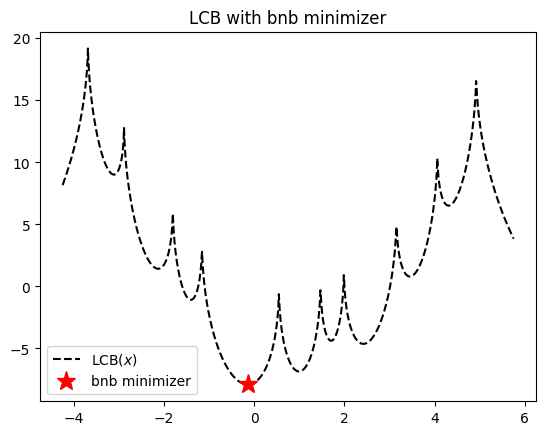

In [28]:
#plt.plot(midpoints, LCB_Ls, label=r"LCB$_{U}(x)$")
plt.plot(X, Y_acqf, 'k--', label=r'LCB$(x)$')
#plt.plot(midpoints, LCB_Us, label=r"LCB$_{L}(x)$")
plt.plot(xstar, y_star[0], "r*", markersize=14, label=r'bnb minimizer')
#plt.plot(x_train[:,0], np.zeros(n_samples), "k*", label=r'training pts')
plt.title('LCB with bnb minimizer'.format(nboxes))
plt.legend()
plt.show()

In [17]:
options = {
    'acquisition_type': 'LCB',
    'acquisition_method' : 'bnb',
    'bo_maxiter': 10, 
    'batch_size': 1,
    'opt_solver': "SLSQP"    
}

In [18]:
from hiopbbpy.opt import BOAlgorithm
bo = BOAlgorithm(problem, gp_model, x_train, y_train, options=options)

hiopbbpy Problem name: QuadraticShift
hiopbbpy Max BO iter: 10
hiopbbpy Optimizing acquisition (LCB) with 10 random initial points
hiopbbpy Batch type: KB
hiopbbpy Batch size: 1
hiopbbpy Internal optimization solver: SLSQP
hiopbbpy Internal optimization solver options: {'maxiter': 200}
hiopbbpy Initial training set: 10 samples, 1 dimensions
hiopbbpy Logger level: INFO


In [19]:
bo.optimize()

hiopbbpy Best UNCONSTRAINED objective from 10 initial samples: 4.1276e-02 
hiopbbpy Best CONSTRAINED objective from 10 feasible initial samples: 4.1276e-02
hiopbbpy *****************************
hiopbbpy Iteration 1/10
hiopbbpy In batch 1/1
hiopbbpy Start finding the best sampling point:


=== Starting Branch & Bound Optimization (Minimization) ===
Initial bounds: l = [-4.25], u = [5.75]
Number of points: 10, Dim = 1

Initial acquisition lower bound: -48.91945794212242
Initial acquisition upper bound: -7.909361502615882

--- Iteration 1 ---
Node bounds: l=[-4.25], u=[5.75]
Node acquisition bounds: L=-48.91945794212242, U=-7.909361502615882
Current best feasible value (GUB): -7.909361502615882
  Branching to child: l=[-4.25], u=[0.75]
  Child acquisition bounds: L=-32.316325124495265, U=-7.909361493728875
  Branching to child: l=[0.75], u=[5.75]
  Child acquisition bounds: L=-32.08576524426579, U=-4.635554957990281
Queue size: 2 | GLB=-32.316325124495265 | GUB=-7.909361502615882 | Gap=24.406963621879385

--- Iteration 2 ---
Node bounds: l=[-4.25], u=[0.75]
Node acquisition bounds: L=-32.316325124495265, U=-7.909361493728875
Current best feasible value (GUB): -7.909361502615882
  Branching to child: l=[-4.25], u=[-1.75]
  Child acquisition bounds: L=-12.540563267457928, U=

  Child acquisition bounds: L=-7.408477647278684, U=-4.635554958092338
  Child pruned: L ≥ GUB - eps.
  Branching to child: l=[2.3125], u=[2.625]
  Child acquisition bounds: L=-7.8629857263966985, U=-6.859391782190549
  Child pruned: L ≥ GUB - eps.
Queue size: 11 | GLB=-10.83820876868366 | GUB=-7.909361503973323 | Gap=2.9288472647103374

--- Iteration 18 ---
Node bounds: l=[-0.1875], u=[0.125]
Node acquisition bounds: L=-10.83820876868366, U=-7.909361503946149
Current best feasible value (GUB): -7.909361503973323
  Branching to child: l=[-0.1875], u=[-0.03125]
  Child acquisition bounds: L=-9.416919622793317, U=-7.909361443863225
  Branching to child: l=[-0.03125], u=[0.125]
  Child acquisition bounds: L=-9.225055472576521, U=-7.909361502865989
Queue size: 12 | GLB=-10.574111572893514 | GUB=-7.909361503973323 | Gap=2.664750068920191

--- Iteration 19 ---
Node bounds: l=[-0.5], u=[-0.1875]
Node acquisition bounds: L=-10.574111572893514, U=-7.909361503961789
Current best feasible value (

  Child acquisition bounds: L=-8.159023884979575, U=-7.9093614166999435
Queue size: 21 | GLB=-8.340078227445634 | GUB=-7.909361503976007 | Gap=0.43071672346962675

--- Iteration 36 ---
Node bounds: l=[1.0625], u=[1.21875]
Node acquisition bounds: L=-8.340078227445634, U=-7.909361503976007
Current best feasible value (GUB): -7.909361503976007
  Branching to child: l=[1.0625], u=[1.140625]
  Child acquisition bounds: L=-7.59430912232308, U=-7.909361421046838
  Child pruned: L ≥ GUB - eps.
  Branching to child: l=[1.140625], u=[1.21875]
  Child acquisition bounds: L=-7.22538047325189, U=-6.859391782190856
  Child pruned: L ≥ GUB - eps.
Queue size: 20 | GLB=-8.331284523869627 | GUB=-7.909361503976007 | Gap=0.4219230198936197

--- Iteration 37 ---
Node bounds: l=[0.046875], u=[0.125]
Node acquisition bounds: L=-8.331284523869627, U=-7.909361503304684
Current best feasible value (GUB): -7.909361503976007
  Branching to child: l=[0.046875], u=[0.0859375]
  Child acquisition bounds: L=-7.98975

  Child acquisition bounds: L=-7.981588411217553, U=-7.909361503877936
  Branching to child: l=[-0.08007812], u=[-0.0703125]
  Child acquisition bounds: L=-7.972927035076993, U=-7.909361503622942
Queue size: 32 | GLB=-8.065900012508854 | GUB=-7.909361503979767 | Gap=0.15653850852908668

--- Iteration 59 ---
Node bounds: l=[-0.2265625], u=[-0.20703125]
Node acquisition bounds: L=-8.065900012508854, U=-7.909361499348132
Current best feasible value (GUB): -7.909361503979767
  Branching to child: l=[-0.2265625], u=[-0.21679688]
  Child acquisition bounds: L=-7.965968203591572, U=-7.909361501408756
  Branching to child: l=[-0.21679688], u=[-0.20703125]
  Child acquisition bounds: L=-7.975288379864304, U=-7.909361503879973
Queue size: 33 | GLB=-8.055028228355013 | GUB=-7.909361503979767 | Gap=0.1456667243752463

--- Iteration 60 ---
Node bounds: l=[-0.0703125], u=[-0.05078125]
Node acquisition bounds: L=-8.055028228355013, U=-7.909361499993954
Current best feasible value (GUB): -7.9093615039

...

  Child acquisition bounds: L=-3.274917724906787, U=-2.3497956078920477
Queue size: 25 | GLB=-4.5467020231067155 | GUB=-3.095309871731902 | Gap=1.4513921513748134

--- Iteration 35 ---
Node bounds: l=[0.75], u=[0.90625]
Node acquisition bounds: L=-4.5467020231067155, U=-2.3478573148897124
Current best feasible value (GUB): -3.095309871731902
  Branching to child: l=[0.75], u=[0.828125]
  Child acquisition bounds: L=-3.1570668521903857, U=-2.349795626887187
  Branching to child: l=[0.828125], u=[0.90625]
  Child acquisition bounds: L=-3.5365014864234237, U=-2.347857399301753
Queue size: 26 | GLB=-4.517473514988189 | GUB=-3.095309871731902 | Gap=1.4221636432562867

--- Iteration 36 ---
Node bounds: l=[1.0625], u=[1.21875]
Node acquisition bounds: L=-4.517473514988189, U=-2.5880689905990573
Current best feasible value (GUB): -3.095309871731902
  Branching to child: l=[1.0625], u=[1.140625]
  Child acquisition bounds: L=-3.6855926149169593, U=-2.5880691895172863
  Branching to child: l=[1.

  Child acquisition bounds: L=-3.3793081223643178, U=-3.0953097581554183
  Branching to child: l=[0.3203125], u=[0.359375]
  Child acquisition bounds: L=-3.0622252625971313, U=-3.0953098716877343
  Child pruned: L ≥ GUB - eps.
Queue size: 30 | GLB=-3.7506482252029216 | GUB=-3.0953098717358416 | Gap=0.65533835346708

--- Iteration 53 ---
Node bounds: l=[-0.8125], u=[-0.65625]
Node acquisition bounds: L=-3.7506482252029216, U=-2.551703478150605
Current best feasible value (GUB): -3.0953098717358416
  Branching to child: l=[-0.8125], u=[-0.734375]
  Child acquisition bounds: L=-2.8590841438702266, U=-2.0535953754555925
  Child pruned: L ≥ GUB - eps.
  Branching to child: l=[-0.734375], u=[-0.65625]
  Child acquisition bounds: L=-2.9301120872495354, U=-2.5517034780759795
  Child pruned: L ≥ GUB - eps.
Queue size: 29 | GLB=-3.72118117194375 | GUB=-3.0953098717358416 | Gap=0.6258713002079084

--- Iteration 54 ---
Node bounds: l=[1.6875], u=[1.765625]
Node acquisition bounds: L=-3.72118117194

  Child acquisition bounds: L=-2.8445563853178153, U=-2.282761184903848
  Child pruned: L ≥ GUB - eps.
Queue size: 23 | GLB=-3.3821711792410527 | GUB=-3.0953098717358416 | Gap=0.2868613075052111

--- Iteration 71 ---
Node bounds: l=[0.125], u=[0.1640625]
Node acquisition bounds: L=-3.3821711792410527, U=-3.095309867508233
Current best feasible value (GUB): -3.0953098717358416
  Branching to child: l=[0.125], u=[0.14453125]
  Child acquisition bounds: L=-3.0617764970466093, U=-3.0953098318986574
  Child pruned: L ≥ GUB - eps.
  Branching to child: l=[0.14453125], u=[0.1640625]
  Child acquisition bounds: L=-3.1790706066549816, U=-3.095309871556137
Queue size: 23 | GLB=-3.3793081223643178 | GUB=-3.0953098717358416 | Gap=0.28399825062847617

--- Iteration 72 ---
Node bounds: l=[0.28125], u=[0.3203125]
Node acquisition bounds: L=-3.3793081223643178, U=-3.0953097581554183
Current best feasible value (GUB): -3.0953098717358416
  Branching to child: l=[0.28125], u=[0.30078125]
  Child acquisi

  Child acquisition bounds: L=-3.073483891097497, U=-3.095309719802673
  Child pruned: L ≥ GUB - eps.
Queue size: 10 | GLB=-3.1717586477040856 | GUB=-3.09530987173624 | Gap=0.0764487759678456

--- Iteration 98 ---
Node bounds: l=[0.28125], u=[0.30078125]
Node acquisition bounds: L=-3.1717586477040856, U=-3.09530971841609
Current best feasible value (GUB): -3.09530987173624
  Branching to child: l=[0.28125], u=[0.29101562]
  Child acquisition bounds: L=-3.063604848829834, U=-3.095309749457002
  Child pruned: L ≥ GUB - eps.
  Branching to child: l=[0.29101562], u=[0.30078125]
  Child acquisition bounds: L=-3.0076510231467837, U=-3.0953098717329053
  Child pruned: L ≥ GUB - eps.
Queue size: 9 | GLB=-3.170438942915027 | GUB=-3.09530987173624 | Gap=0.07512907117878687

--- Iteration 99 ---
Node bounds: l=[1.0625], u=[1.1015625]
Node acquisition bounds: L=-3.170438942915027, U=-2.8152235798358554
Current best feasible value (GUB): -3.09530987173624
  Branching to child: l=[1.0625], u=[1.0820

hiopbbpy   (mu, sigma) at new sample x: 0.33431054817482053, 1.1429793637991355 
hiopbbpy Best objective found in this iteration: 2.8327e-01 
hiopbbpy Training set size is now 20
hiopbbpy Current best objective: 2.3842e-05 (previous best: 2.3842e-05)
hiopbbpy Objective function improvement: 0.0000e+00
hiopbbpy ===================================
hiopbbpy Bayesian Optimization completed
hiopbbpy Total evaluations for initial samples: 10
hiopbbpy Total evaluations for BO iterations: 10
hiopbbpy Optimal at BO iteration: 8 
hiopbbpy Best value: 2.384185791015625e-05
hiopbbpy ===================================


In [23]:
x_bo = bo.getOptimizationHistory()[0]
print(x_bo[i])

[0.21777344]


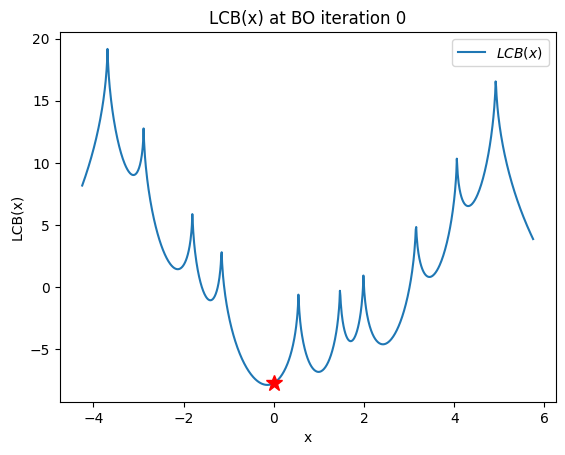

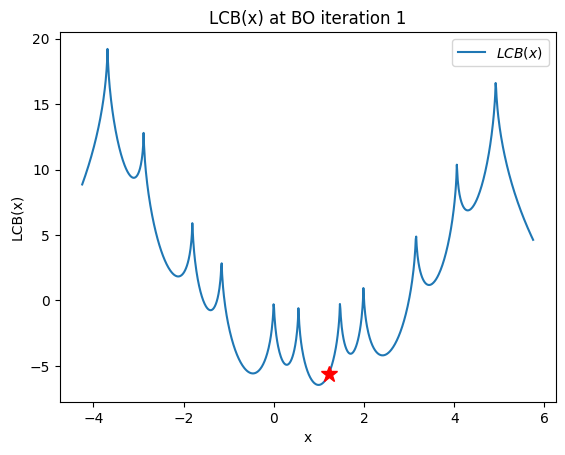

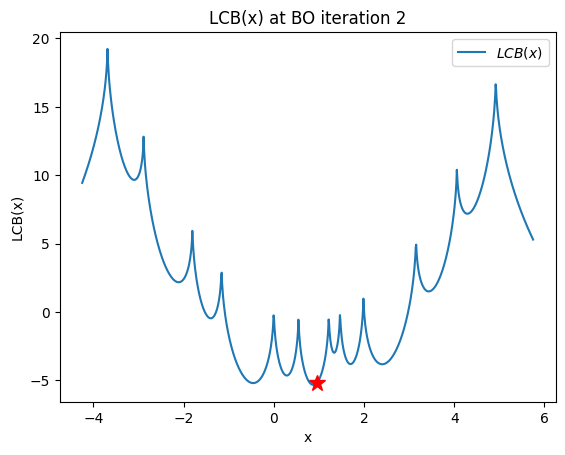

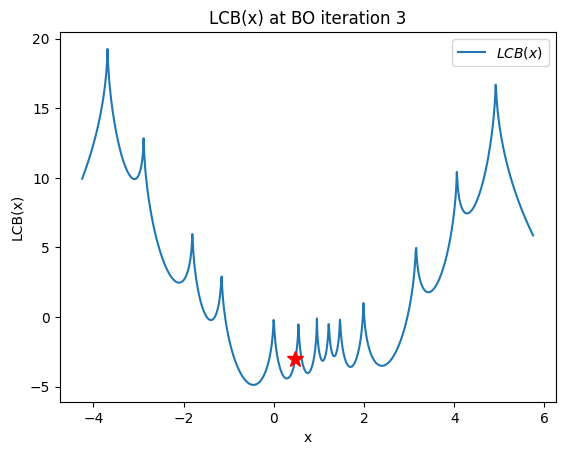

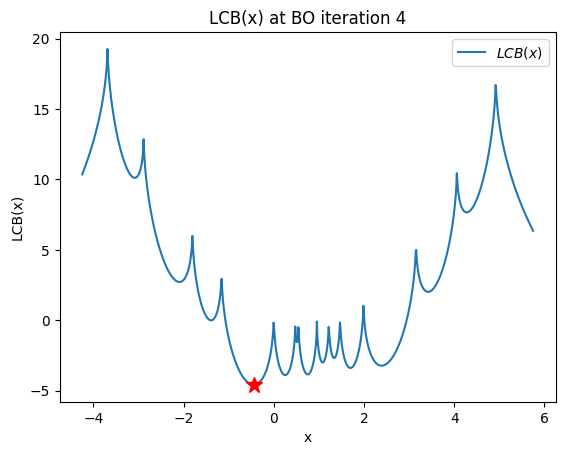

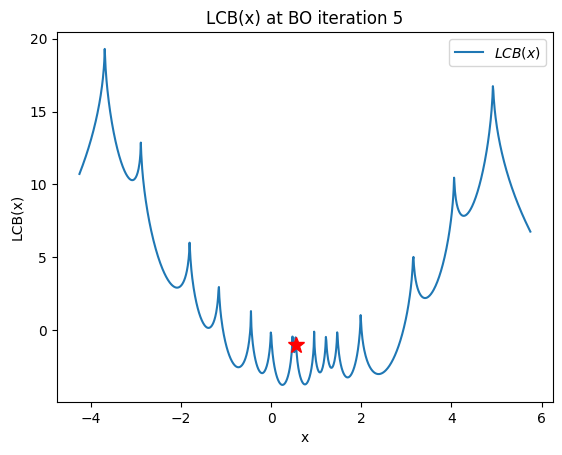

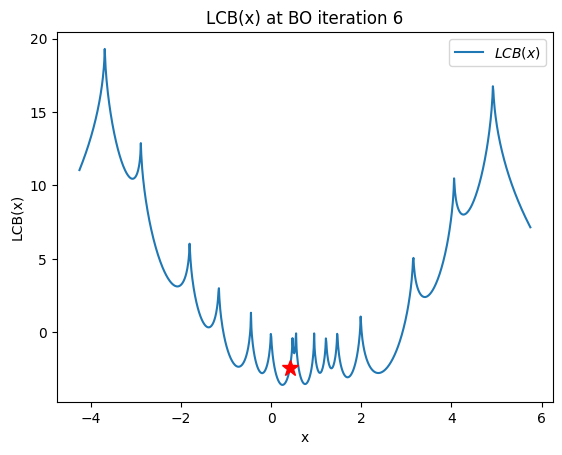

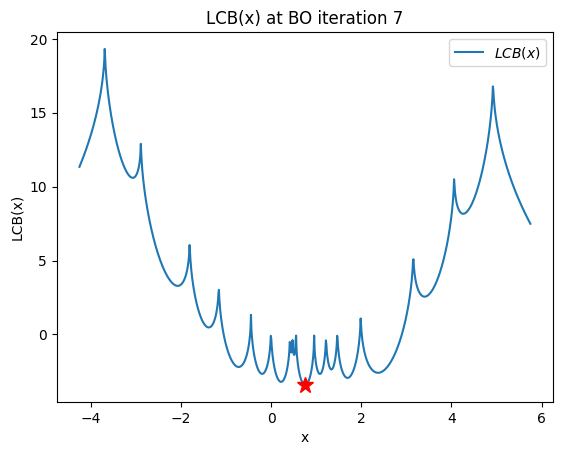

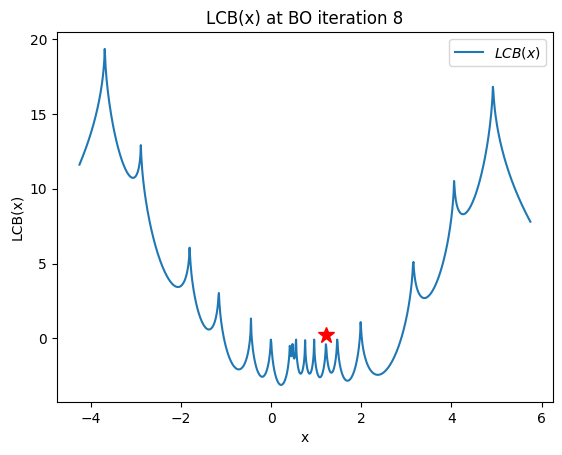

/home/tucker/anaconda3/envs/hiopbbpy/lib/python3.9/site-packages/smt/surrogate_models/krg_based.py:536: UserWarning: Warning: multiple x input features have the same value (at least same row twice).
  warnings.warn(


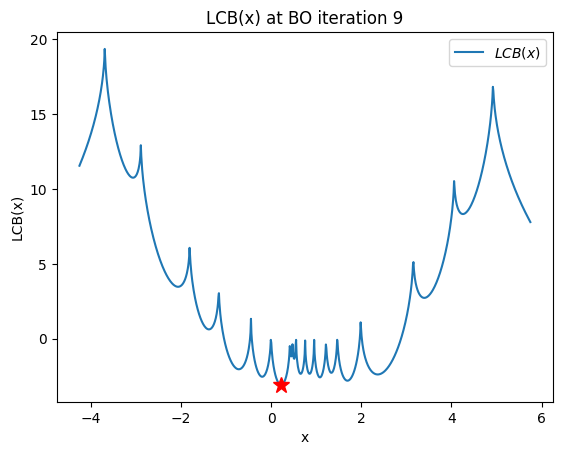

In [29]:
x_train_superset = np.concatenate((x_train, x_bo), axis=0)
for i in range(x_bo.shape[0]):
    x_train2 = x_train_superset[:-10+i]
    y_train2 = problem.evaluate(x_train2)
    gp_model2 = smtKRG(theta, problem.xlimits, nx)
    gp_model2.train(x_train2, y_train2)
    acqf2 = LCBacquisition(gp_model2, beta=beta)
    Y_acqf2 = acqf2.evaluate(X)
    y_star2 = acqf2.evaluate(np.atleast_2d(x_bo[i]))
    plt.plot(X, Y_acqf2, label=r'$LCB(x)$')
    plt.plot(x_bo[i], y_star2, r'r*', markersize=12)
    #plt.plot(X, muX, "-.", label=r'$\mu(x)$')
    #plt.plot(X, sigmaX, label=r'$\sigma(x)$')
    plt.xlabel("x")
    plt.ylabel("LCB(x)")
    plt.legend()
    plt.title(r"LCB(x) at BO iteration {0:d}".format(i))
    plt.show()
    
    